In [19]:
import os
import cv2
import json
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt

import torch

from ultralytics import YOLO

In [20]:
import ultralytics
import cv2

print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)

Ultralytics: 8.4.100
OpenCV: 4.13.0
PyTorch: 2.11.0+cu128


In [21]:
model = YOLO("yolov8n.pt")

print("YOLO Loaded Successfully!")

YOLO Loaded Successfully!


In [9]:
!pip install -q kagglehub

In [26]:
import kagglehub

path = kagglehub.dataset_download(
    "salviohexia/isic-2019-skin-lesion-images-for-classification"
)

print(path)

Using Colab cache for faster access to the 'isic-2019-skin-lesion-images-for-classification' dataset.
/kaggle/input/isic-2019-skin-lesion-images-for-classification


In [28]:
dataset_path = "/kaggle/input/isic-2019-skin-lesion-images-for-classification"

classes = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

In [29]:
from collections import OrderedDict
import os

class_counts = OrderedDict()

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)

    image_files = [
        f for f in os.listdir(class_dir)
        if f.endswith(".jpg")
    ]

    class_counts[cls] = len(image_files)

print("Image count per class:\n")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", sum(class_counts.values()))

Image count per class:

AK: 867
BCC: 3323
BKL: 2624
DF: 239
MEL: 4522
NV: 12875
SCC: 628
VASC: 253

Total images: 25331


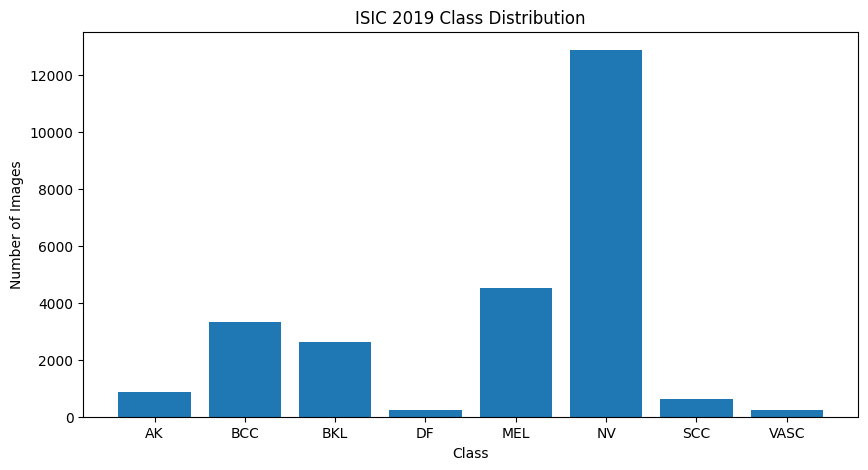

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("ISIC 2019 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

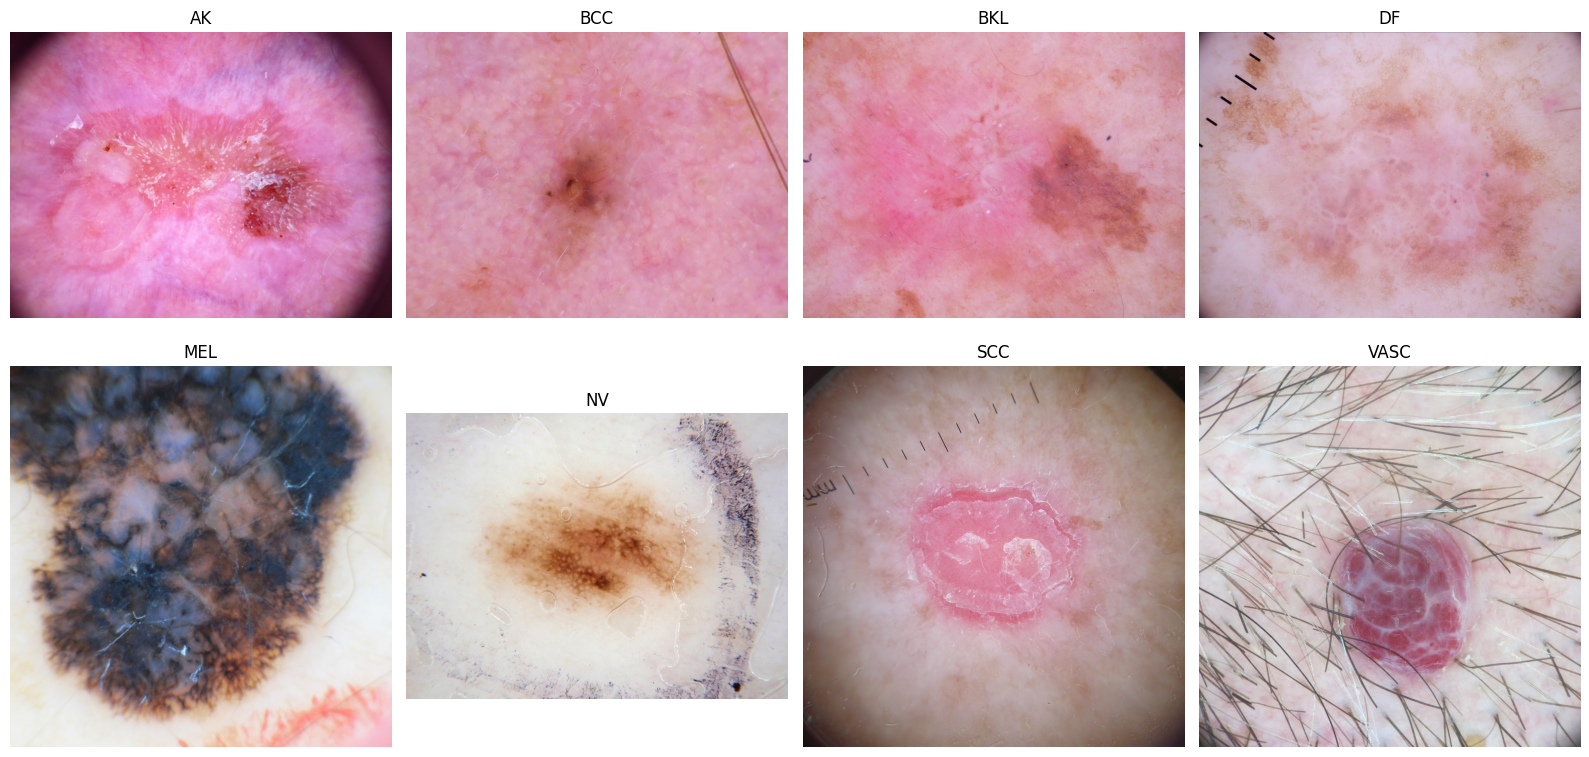

In [31]:
import random
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls)
    img_name = random.choice([
        f for f in os.listdir(class_dir)
        if f.endswith('.jpg')
    ])

    img_path = os.path.join(class_dir, img_name)
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [32]:
import os

base_path = "/content/skin_dataset"

for split in ["train", "val", "test"]:
    for cls in ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]:
        os.makedirs(os.path.join(base_path, split, cls), exist_ok=True)

print("Directories created successfully!")

Directories created successfully!


In [33]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Dataset location
dataset_path = "/kaggle/input/isic-2019-skin-lesion-images-for-classification"

# New dataset location
output_path = "/content/skin_dataset"

classes = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]

for split in ["train","val","test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [34]:
for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = os.listdir(class_path)

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    print(f"{cls}")

    print("Train :", len(train_imgs))
    print("Val   :", len(val_imgs))
    print("Test  :", len(test_imgs))

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(output_path,"train",cls,img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(output_path,"val",cls,img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(output_path,"test",cls,img)
        )

print("\nDataset Split Complete!")

AK
Train : 606
Val   : 130
Test  : 131
BCC
Train : 2326
Val   : 498
Test  : 499
BKL
Train : 1836
Val   : 394
Test  : 394
DF
Train : 167
Val   : 36
Test  : 36
MEL
Train : 3165
Val   : 678
Test  : 679
NV
Train : 9012
Val   : 1931
Test  : 1932
SCC
Train : 439
Val   : 94
Test  : 95
VASC
Train : 177
Val   : 38
Test  : 38

Dataset Split Complete!


In [22]:
for split in ["train","val","test"]:

    total = 0

    print("\n",split.upper())

    for cls in classes:

        n = len(os.listdir(os.path.join(output_path,split,cls)))

        total += n

        print(f"{cls:5s} : {n}")

    print("Total =",total)


 TRAIN
AK    : 606
BCC   : 2326
BKL   : 1836
DF    : 167
MEL   : 3165
NV    : 9012
SCC   : 439
VASC  : 177
Total = 17728

 VAL
AK    : 130
BCC   : 498
BKL   : 394
DF    : 36
MEL   : 678
NV    : 1931
SCC   : 94
VASC  : 38
Total = 3799

 TEST
AK    : 131
BCC   : 499
BKL   : 394
DF    : 36
MEL   : 679
NV    : 1932
SCC   : 95
VASC  : 38
Total = 3804


In [23]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.RandomAffine(
        degrees=15,
        translate=(0.1,0.1)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [24]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(
    "/content/skin_dataset/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    "/content/skin_dataset/val",
    transform=val_transform
)

test_dataset = ImageFolder(
    "/content/skin_dataset/test",
    transform=val_transform
)

print(train_dataset.classes)

['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [25]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

554
119
119


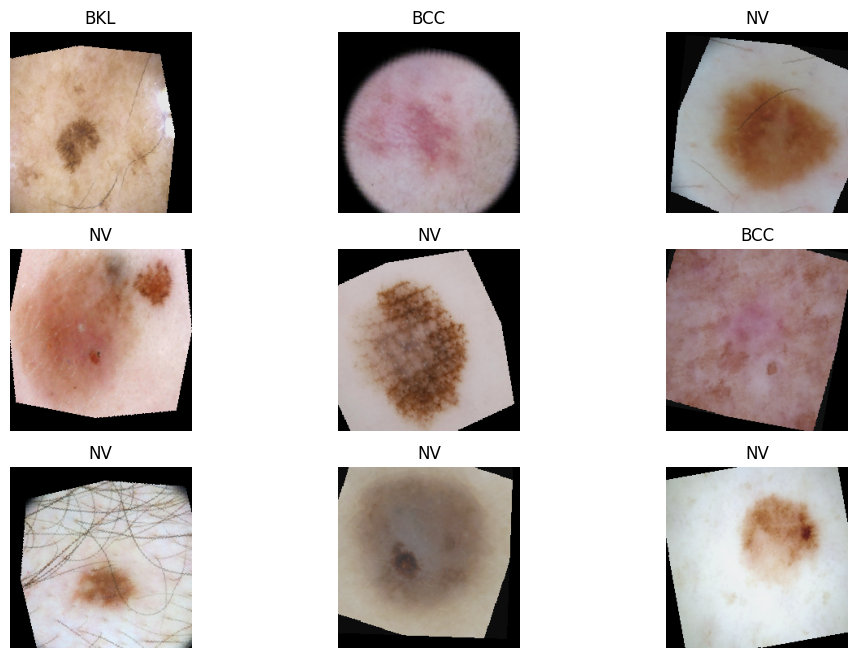

In [26]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = images[i].permute(1,2,0).numpy()

    img = img * [0.229,0.224,0.225] + [0.485,0.456,0.406]

    plt.imshow(img)

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.show()

Training EfficientNet-B0


In [27]:
import torch
import torch.nn as nn
from torchvision import models

In [29]:
model = models.efficientnet_b0(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


In [30]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    8
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


In [31]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_dataset.targets

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

weights = torch.tensor(weights,dtype=torch.float).to(device)

print(weights)

tensor([ 3.6568,  0.9527,  1.2070, 13.2695,  0.7002,  0.2459,  5.0478, 12.5198], device='cuda:0')


In [32]:
criterion = nn.CrossEntropyLoss(
    weight=weights
)

In [33]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=0.0001,

    weight_decay=1e-4

)

In [34]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='min',

    factor=0.5,

    patience=2
)

In [35]:
def accuracy(outputs, labels):

    _, preds = torch.max(outputs,1)

    correct = (preds==labels).sum().item()

    return correct/len(labels)

In [36]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    running_acc = 0

    for images,labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_acc += accuracy(outputs,labels)

    return running_loss/len(loader), running_acc/len(loader)

In [37]:
def validate(model, loader):

    model.eval()

    running_loss = 0
    running_acc = 0

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs,labels)

            running_loss += loss.item()

            running_acc += accuracy(outputs,labels)

    return running_loss/len(loader), running_acc/len(loader)

In [39]:
EPOCHS = 8

best_loss = 999

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss,train_acc = train_one_epoch(model,train_loader)

    val_loss,val_acc = validate(model,val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    print("--------------------------------")

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(

            model.state_dict(),

            "best_skin_model.pth"

        )

        print("Best Model Saved\n")

Epoch 1
Train Loss : 1.0126
Train Acc  : 0.6435
Val Loss   : 1.1001
Val Acc    : 0.5944
--------------------------------
Best Model Saved

Epoch 2
Train Loss : 0.8707
Train Acc  : 0.6707
Val Loss   : 0.8592
Val Acc    : 0.6860
--------------------------------
Best Model Saved

Epoch 3
Train Loss : 0.7901
Train Acc  : 0.6909
Val Loss   : 0.9201
Val Acc    : 0.6670
--------------------------------
Epoch 4
Train Loss : 0.7111
Train Acc  : 0.7101
Val Loss   : 0.8058
Val Acc    : 0.7016
--------------------------------
Best Model Saved

Epoch 5
Train Loss : 0.6501
Train Acc  : 0.7296
Val Loss   : 0.7674
Val Acc    : 0.7173
--------------------------------
Best Model Saved

Epoch 6
Train Loss : 0.5906
Train Acc  : 0.7429
Val Loss   : 0.7779
Val Acc    : 0.7181
--------------------------------
Epoch 7
Train Loss : 0.5357
Train Acc  : 0.7562
Val Loss   : 0.7478
Val Acc    : 0.7292
--------------------------------
Best Model Saved

Epoch 8
Train Loss : 0.5235
Train Acc  : 0.7666
Val Loss   : 0.

In [40]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights=None)

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 8)

model.load_state_dict(torch.load("best_skin_model.pth", map_location=device))
model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [41]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.7513144058885384


In [42]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

          AK       0.38      0.84      0.52       131
         BCC       0.78      0.74      0.76       499
         BKL       0.56      0.62      0.59       394
          DF       0.57      0.81      0.67        36
         MEL       0.69      0.65      0.67       679
          NV       0.90      0.81      0.86      1932
         SCC       0.57      0.59      0.58        95
        VASC       0.45      0.84      0.59        38

    accuracy                           0.75      3804
   macro avg       0.61      0.74      0.65      3804
weighted avg       0.78      0.75      0.76      3804



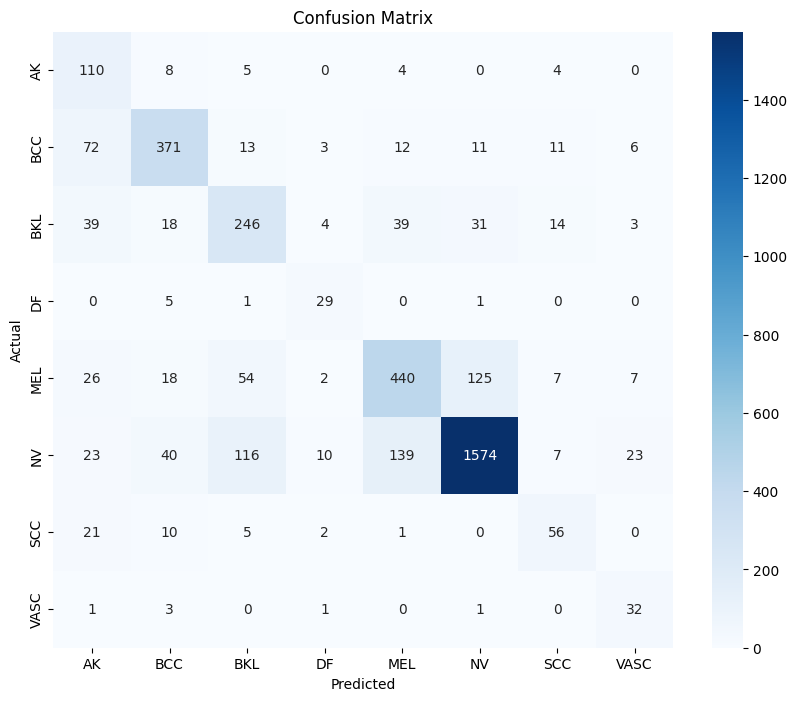

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Making explainable AI using Grad-CAM

In [44]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=155b86fdf9f0d877d6e59feefd1e9b21da263747f4990292216d44aff70c371e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch

from torchvision import transforms

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import show_cam_on_image

In [46]:
target_layers = [model.features[-1]]

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [47]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-07-18 230930.png to Screenshot 2026-07-18 230930.png


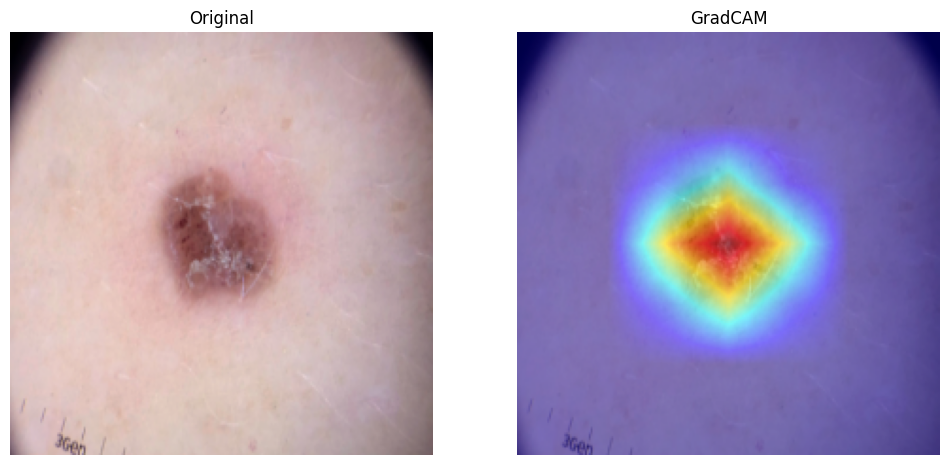

In [48]:
image_path = list(uploaded.keys())[0]

rgb_img = np.array(Image.open(image_path).convert("RGB"))

rgb_img = cv2.resize(rgb_img,(224,224))

input_tensor = transform(Image.fromarray(rgb_img)).unsqueeze(0).to(device)

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(input_tensor=input_tensor)[0]

visualization = show_cam_on_image(
    rgb_img.astype(np.float32)/255.0,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("GradCAM")
plt.axis("off")

plt.show()

In [49]:
classes = train_dataset.classes

with torch.no_grad():

    output = model(input_tensor)

    probs = torch.softmax(output,dim=1)

    confidence,pred = torch.max(probs,1)

print("Prediction :",classes[pred.item()])

print("Confidence :",confidence.item()*100)

Prediction : BKL
Confidence : 95.03967761993408
